#### 1. Análise inicial

In [1]:
# Importando as bibliotecas
import pandas as pd

# Carregando a base de dados
base_dados = pd.read_csv('titanic.csv', sep = ';', decimal=',')# Visualizando as primeiras linhas da base
df = base_dados

In [12]:
print(base_dados.head())

  sobreviveu    classe       sexo idade  irmaos_conjuges  pais_filhos  \
0        nao  terceira  masculino    22                1            0   
1        sim  primeira   feminino    38                1            0   
2        sim  terceira   feminino    26                0            0   
3        sim  primeira   feminino    35                1            0   
4        nao  terceira  masculino    35                0            0   

  valor_tarifa nivel_cabine     embarque  
0         7,25          NaN  Southampton  
1        71,28            C    Cherbourg  
2         7,93          NaN  Southampton  
3        53,10            C  Southampton  
4         8,05          NaN  Southampton  


In [ ]:
print(base_dados.shape)

(891, 9)


In [2]:
# Mostra os valores únicos (ex: [1, 2, 3])
print(df['classe'].unique())

<StringArray>
['terceira', 'primeira', 'segunda']
Length: 3, dtype: str


In [36]:
# 1. Arredonda (0 casas decimais)
# 2. Converte para Int64 (o 'I' maiúsculo aceita valores nulos)
df['idade'] = df['idade'].round(0).astype('Int64')

In [40]:
print(base_dados.dtypes)

sobreviveu             str
classe                 str
sexo                   str
idade                Int64
irmaos_conjuges      int64
pais_filhos          int64
valor_tarifa       float64
nivel_cabine           str
embarque               str
dtype: object


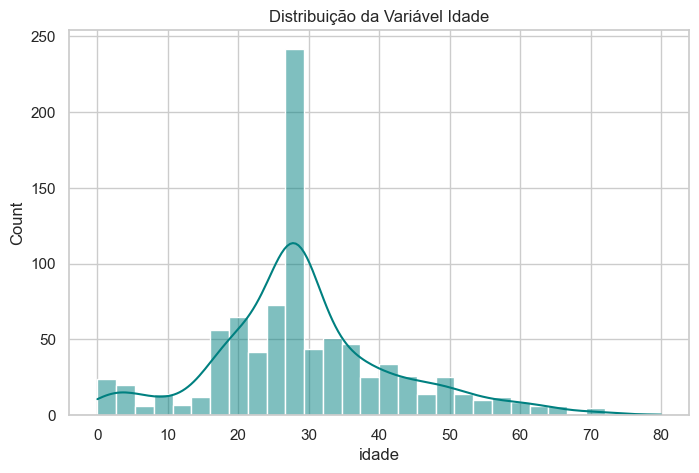

In [37]:
plt.figure(figsize=(8, 5))
sns.histplot(df['idade'], kde=True, color='teal')
plt.title('Distribuição da Variável Idade')
plt.show()

In [41]:
# Calculando a média e o desvio padrão
media = df['idade'].mean()
desvio = df['idade'].std()

# Aplicando a fórmula do Z-Score
df['idade_zscore'] = (df['idade'] - media) / desvio

print(df[['idade', 'idade_zscore']].head())

   idade  idade_zscore
0     22     -0.565141
1     38      0.663944
2     26      -0.25787
3     35       0.43349
4     35       0.43349


In [38]:
mediana = df['idade'].median()
df['idade'] = df['idade'].fillna(mediana)

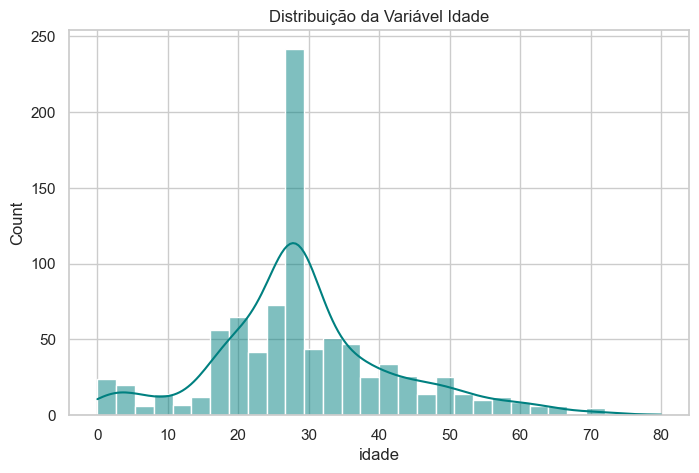

In [39]:
plt.figure(figsize=(8, 5))
sns.histplot(df['idade'], kde=True, color='teal')
plt.title('Distribuição da Variável Idade')
plt.show()

#### 2. Boxplot

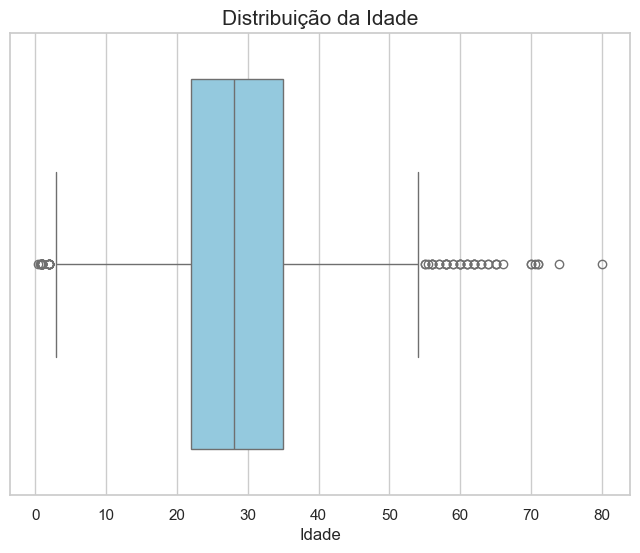

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# Definindo o estilo visual
sns.set_theme(style="whitegrid")

# Criando o boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x=base_dados['idade'], color='skyblue')

# Adicionando títulos e rótulos
plt.title('Distribuição da Idade', fontsize=15)
plt.xlabel('Idade')

# Exibindo o gráfico
plt.show()

#### 3. DBSCAN

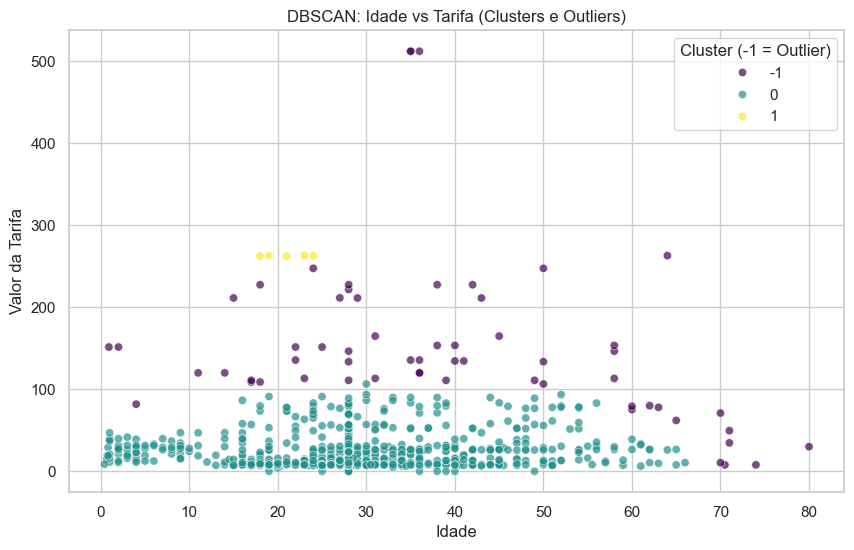

In [34]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

df = base_dados
# 1. Tratamento do erro '28,5' (Conversão de vírgula para ponto)
# Convertendo para string primeiro para garantir que o .str funcione
df['idade'] = df['idade'].astype(str).str.replace(',', '.')
df['idade'] = pd.to_numeric(df['idade'], errors='coerce')

# 2. Limpeza de valores nulos (DBSCAN não aceita NaNs)
df_clean = df[['idade', 'valor_tarifa']].dropna()

# 3. Normalização (Essencial para algoritmos de distância)
scaler = StandardScaler()
dados_scaled = scaler.fit_transform(df_clean)

# 4. Configurando e aplicando o DBSCAN
# eps: raio da vizinhança | min_samples: pontos mínimos para um cluster
dbscan = DBSCAN(eps=0.3, min_samples=5)
df_clean['cluster'] = dbscan.fit_predict(dados_scaled)

# 5. Visualização Corrigida (usando 'marker' em vez de 'pch')
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_clean, 
    x='idade', 
    y='valor_tarifa', 
    hue='cluster', 
    palette='viridis', 
    marker='o',  # O 'pch' do R aqui é 'marker'
    alpha=0.7
)

plt.title('DBSCAN: Idade vs Tarifa (Clusters e Outliers)')
plt.xlabel('Idade')
plt.ylabel('Valor da Tarifa')
plt.legend(title='Cluster (-1 = Outlier)')
plt.show()

In [22]:
pip install scikit-learn

   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ------------------------ --------------- 5.0/8.0 MB 30.8 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 27.1 MB/s  0:00:00
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   ------- -------------------------------- 6.8/36.5 MB 34.0 MB/s eta 0:00:01
   --------------- ------------------------ 14.4/36.5 MB 35.8 MB/s eta 0:00:01
   ------------------------ --------------- 22.5/36.5 MB 36.4 MB/s eta 0:00:01
   --------------------------------- ------ 30.4/36.5 MB 36.5 MB/s eta 0:00:01
   ---------------------------------------  36.4/36.5 MB 37.3 MB/s eta 0:00:01
   ---------------------------------------- 36.5/36.5 MB 32.2 MB/s  0:00:01

   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- -

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# 1. Limpeza (Z-score não aceita nulos)
idade_limpa = df['idade'].dropna()

# 2. Cálculo do Z-score
idade_z = stats.zscore(idade_limpa)

# 3. Visualização
plt.figure(figsize=(10, 6))
sns.histplot(idade_z, kde=True, color='purple', alpha=0.4)

# Adicionando linhas de referência
plt.axvline(x=0, color='red', linestyle='-', linewidth=2, label='Média (Z=0)')
plt.axvline(x=1, color='orange', linestyle='--', linewidth=1.5, label='1 Desvio Padrão (+1)')
plt.axvline(x=-1, color='orange', linestyle='--', linewidth=1.5, label='1 Desvio Padrão (-1)')
plt.axvline(x=3, color='black', linestyle=':', linewidth=1.5, label='Limite de Outlier (+3)')
plt.axvline(x=-3, color='black', linestyle=':', linewidth=1.5, label='Limite de Outlier (-3)')

plt.title('Distribuição Padronizada (Z-Score) da Idade', fontsize=15)
plt.xlabel('Z-Score da Idade')
plt.ylabel('Frequência')
plt.legend()
plt.show()

Gráficos de variáveis

In [30]:
import pandas as pd

# 1. Definindo os cortes personalizados
# 0-24, 25-49, 50-59, e 60+ (até 100)
bins = [0, 25, 50, 60, 100]
labels = ['0-24', '25-49', '50-59', '60+']

# 2. Criando a nova coluna de faixas
df['faixa_agrupada'] = pd.cut(df['idade'], bins=bins, labels=labels, right=False)

# 3. Gerando a tabela de taxas reais
tabela_senior = df.groupby('faixa_agrupada').agg(
    total_pessoas=('sobreviveu_num', 'count'),
    total_sobreviventes=('sobreviveu_num', 'sum'),
    taxa_real=('sobreviveu_num', 'mean')
).reset_index()

# 4. Formatação para o print
tabela_senior['taxa_formatada'] = (tabela_senior['taxa_real'] * 100).round(2).astype(str) + '%'

print("Análise com Grupo Sênior Agrupado:")
print(tabela_senior[['faixa_agrupada', 'total_pessoas', 'total_sobreviventes', 'taxa_formatada']])

Análise com Grupo Sênior Agrupado:
  faixa_agrupada  total_pessoas  total_sobreviventes taxa_formatada
0           0-24            278                  118         42.45%
1          25-49            362                  145         40.06%
2          50-59             48                   20         41.67%
3            60+             26                    7         26.92%


C:\Users\geova\AppData\Local\Temp\ipykernel_4252\2502083278.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


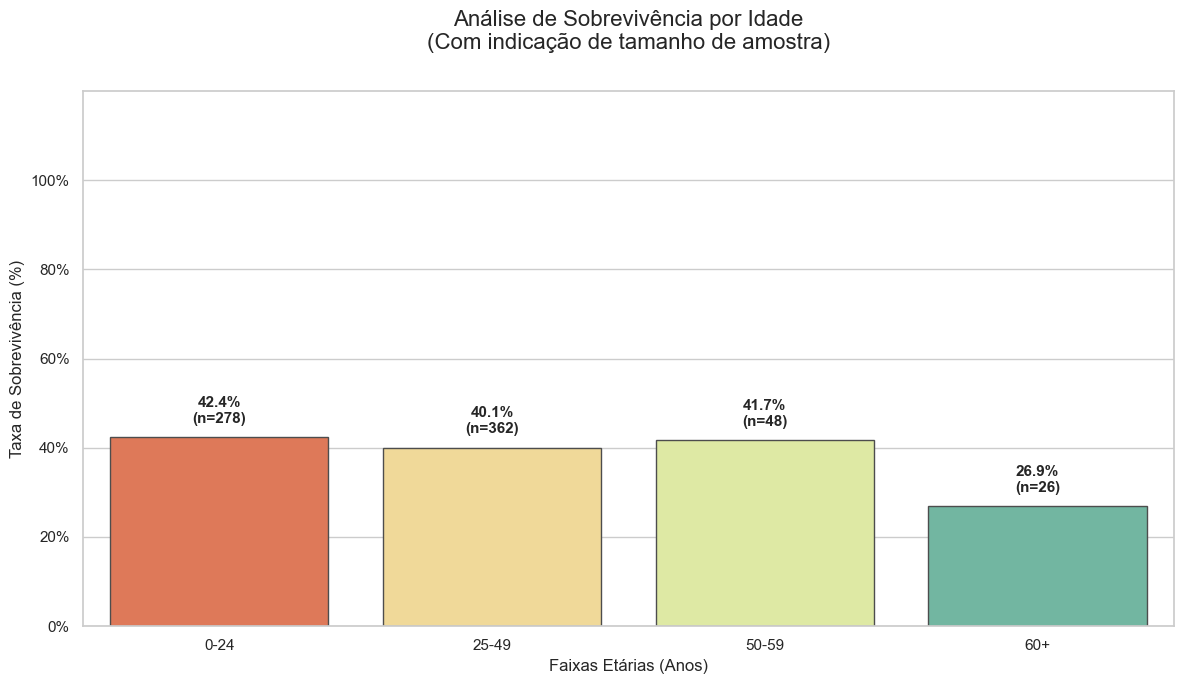

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Configurações Visuais
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# 2. Criando o gráfico
# Usamos uma paleta de cores que vai do frio (menor taxa) ao quente (maior taxa)
ax = sns.barplot(
    data=tabela_senior, 
    x='faixa_agrupada', 
    y='taxa_real', 
    palette='Spectral',
    edgecolor='0.3'
)

# 3. Mágica dos Rótulos: % + n (amostra)
for i, p in enumerate(ax.patches):
    taxa = tabela_senior.iloc[i]['taxa_real'] * 100
    n_total = tabela_senior.iloc[i]['total_pessoas']
    
    # Criamos uma string com a porcentagem e o total de pessoas abaixo
    label = f'{taxa:.1f}%\n(n={n_total})'
    
    ax.annotate(label, 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=11, fontweight='bold', 
                xytext=(0, 8), 
                textcoords='offset points')

# 4. Ajustes de Eixos e Títulos
plt.title('Análise de Sobrevivência por Idade\n(Com indicação de tamanho de amostra)', fontsize=16, pad=30)
plt.ylabel('Taxa de Sobrevivência (%)', fontsize=12)
plt.xlabel('Faixas Etárias (Anos)', fontsize=12)
plt.ylim(0, 1.2) # Espaço para os rótulos não serem cortados

# Transforma o eixo Y em porcentagem real
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0], ['0%', '20%', '40%', '60%', '80%', '100%'])

plt.tight_layout()
plt.show()

In [21]:
# 1. Agrupando por Classe e Sexo ao mesmo tempo
tabela_cruzada = df.groupby(['classe', 'sexo']).agg(
    total_passageiros=('sobreviveu_num', 'count'),
    total_sobreviventes=('sobreviveu_num', 'sum'),
    taxa_sobrevivencia=('sobreviveu_num', 'mean')
).reset_index()

# 2. Formatando a taxa para leitura fácil
tabela_cruzada['taxa_sobrevivencia'] = (tabela_cruzada['taxa_sobrevivencia'] * 100).round(2).astype(str) + '%'

print(tabela_cruzada)

     classe       sexo  total_passageiros  total_sobreviventes  \
0  primeira   feminino                 94                   91   
1  primeira  masculino                122                   45   
2   segunda   feminino                 76                   70   
3   segunda  masculino                108                   17   
4  terceira   feminino                144                   72   
5  terceira  masculino                347                   47   

  taxa_sobrevivencia  
0             96.81%  
1             36.89%  
2             92.11%  
3             15.74%  
4              50.0%  
5             13.54%  


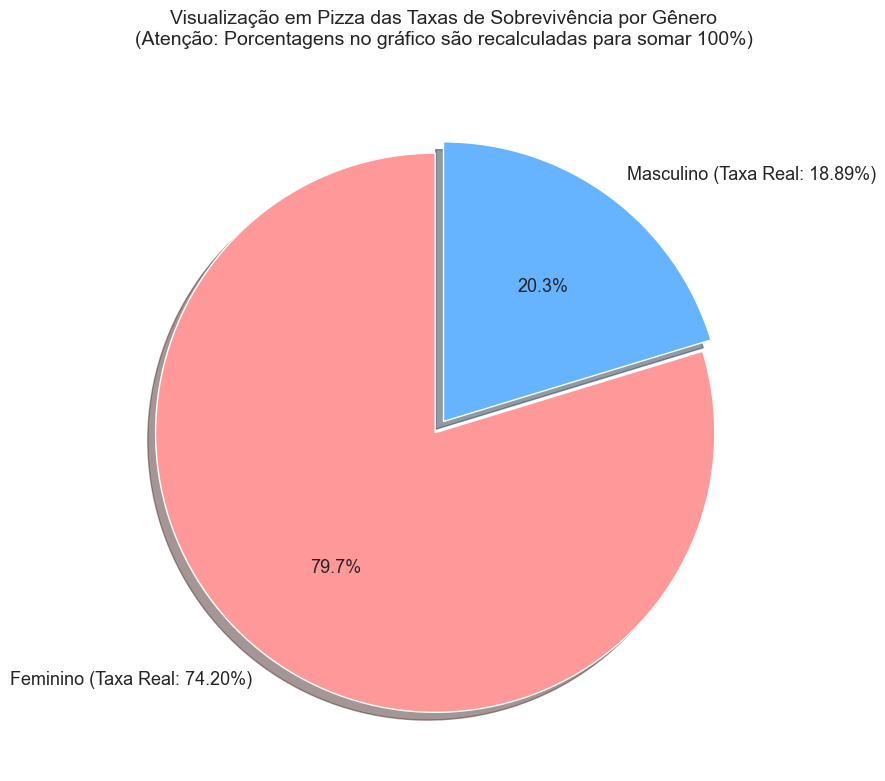

In [25]:
import matplotlib.pyplot as plt

# 1. Dados da Taxa Real (Independentes)
labels = ['Feminino (Taxa Real: 74.20%)', 'Masculino (Taxa Real: 18.89%)']
taxas_reais = [74.20, 18.89] # Valores originais
cores = ['#ff9999', '#66b3ff'] # Rosa claro e Azul claro

# 2. Criando a figura
plt.figure(figsize=(9, 9))

# 3. Plotando a pizza
# O 'autopct' vai mostrar as porcentagens RECALCULADAS pelo gráfico (79.7% e 20.3%)
plt.pie(taxas_reais, 
        labels=labels, 
        autopct='%1.1f%%', 
        startangle=90, 
        colors=cores, 
        explode=(0.05, 0), # Destaca levemente a fatia feminina
        shadow=True,
        textprops={'fontsize': 13})

# 4. Detalhes finais
plt.title('Visualização em Pizza das Taxas de Sobrevivência por Gênero\n(Atenção: Porcentagens no gráfico são recalculadas para somar 100%)', fontsize=14, pad=20)
plt.tight_layout()

# 5. Exibindo
plt.show()

In [22]:
# Gerando a tabela de taxa real por classe
tabela_classe_real = df.groupby('classe').agg(
    total_passageiros=('sobreviveu_num', 'count'),
    total_sobreviventes=('sobreviveu_num', 'sum'),
    taxa_sobrevivencia=('sobreviveu_num', 'mean')
).reset_index()

# Formatando para porcentagem
tabela_classe_real['taxa_sobrevivencia'] = (tabela_classe_real['taxa_sobrevivencia'] * 100).round(2).astype(str) + '%'

print(tabela_classe_real)

     classe  total_passageiros  total_sobreviventes taxa_sobrevivencia
0  primeira                216                  136             62.96%
1   segunda                184                   87             47.28%
2  terceira                491                  119             24.24%


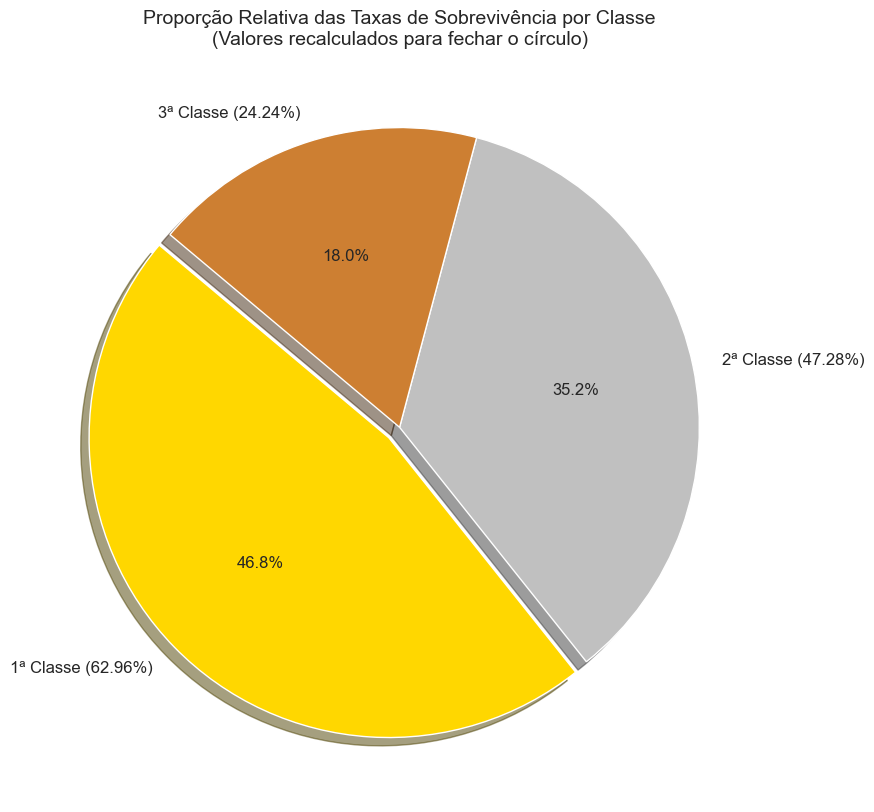

In [26]:
import matplotlib.pyplot as plt

# 1. Taxas Reais de cada classe
labels = ['1ª Classe (62.96%)', '2ª Classe (47.28%)', '3ª Classe (24.24%)']
taxas_reais = [62.96, 47.28, 24.24]
cores = ['#ffd700', '#c0c0c0', '#cd7f32'] # Ouro, Prata e Bronze

plt.figure(figsize=(9, 9))

# 2. Gerando a pizza
# O autopct mostrará quanto cada taxa representa do total de 134.48
plt.pie(taxas_reais, 
        labels=labels, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=cores, 
        explode=(0.05, 0, 0), 
        shadow=True,
        textprops={'fontsize': 12})

plt.title('Proporção Relativa das Taxas de Sobrevivência por Classe\n(Valores recalculados para fechar o círculo)', fontsize=14)
plt.tight_layout()
plt.show()

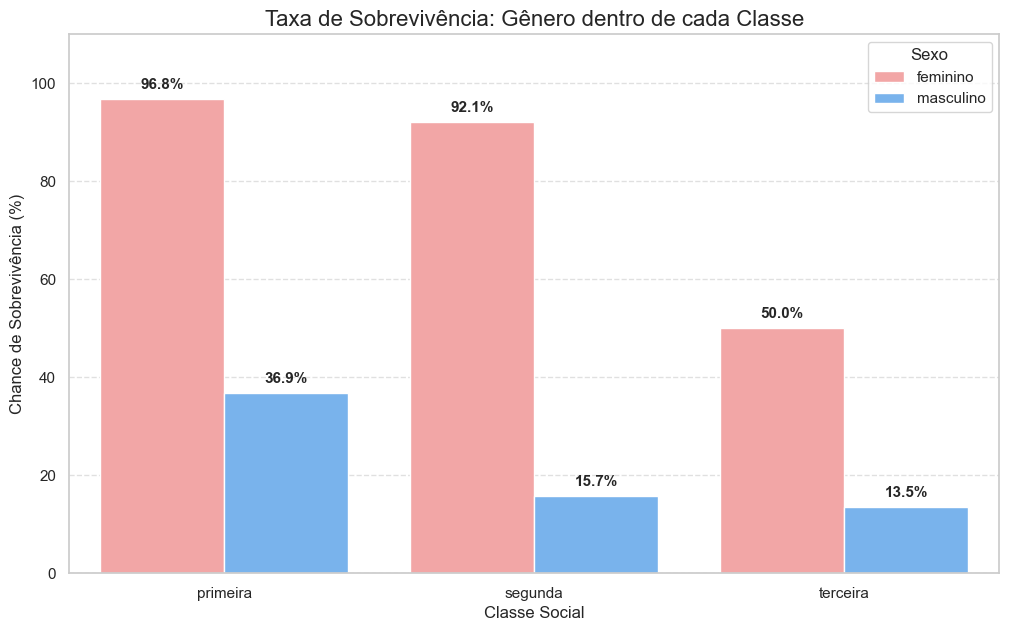

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculando a taxa real agrupada por classe e sexo
tabela_cruzada = df.groupby(['classe', 'sexo']).agg(
    taxa_sobrevivencia=('sobreviveu_num', 'mean')
).reset_index()

# Converte para porcentagem (0.96 -> 96.0)
tabela_cruzada['taxa_sobrevivencia'] *= 100

# 2. Criando o gráfico de barras agrupadas
plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=tabela_cruzada, 
    x='classe', 
    y='taxa_sobrevivencia', 
    hue='sexo', 
    palette=['#ff9999', '#66b3ff'] # Rosa para mulheres, Azul para homens
)

# 3. Adicionando os rótulos de porcentagem exata
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.1f}%', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', 
                    fontsize=11, fontweight='bold', xytext=(0, 5),
                    textcoords='offset points')

# 4. Ajustes de layout
plt.title('Taxa de Sobrevivência: Gênero dentro de cada Classe', fontsize=16)
plt.ylabel('Chance de Sobrevivência (%)')
plt.xlabel('Classe Social')
plt.ylim(0, 110) # Espaço extra para as etiquetas no topo
plt.legend(title='Sexo')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

In [2]:
git --version

NameError: name 'git' is not defined